# From Data and lection, as slhedure

go to ## learning etap

## 1. What is a classification?

Classification is a **supervised** learning task:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad y_i \in \{0, 1, \dots, K-1\}
$$

We already know the correct label during training and want a rule

$$
\hat{y} = f(x)
$$

that generalizes to new objects.

For binary classification, we often care about

$$
P(y=1 \mid x)
$$

Typical examples: spam vs not spam, churn vs stay, benign vs malignant.


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_breast_cancer,
    load_wine,
    make_classification,
    make_moons,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC

In [3]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

ink = "#2f2a34"
paper = "#f6f1e7"
panel = "#efe4d6"
grid = "#ccbda8"

sns.set_theme(
    context="talk",
    style="ticks",
    palette=["#ff6b6b", "#1982c4", "#ffd166", "#2a9d8f", "#6a4c93"],
    rc={
        "figure.facecolor": paper,
        "axes.facecolor": panel,
        "savefig.facecolor": paper,
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "text.color": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "grid.color": grid,
        "grid.linestyle": ":",
        "grid.alpha": 0.55,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "legend.frameon": True,
        "legend.facecolor": "#fbf7f0",
        "legend.edgecolor": grid,
    },
)

surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)
warm_cmap = sns.blend_palette(["#fff1d0", "#f4a261", "#e76f51"], as_cmap=True)
cool_cmap = sns.blend_palette(["#e0fbfc", "#4ea8de", "#293241"], as_cmap=True)
class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.DataFrame(
        {"metric": list(rows.keys()), "value": list(rows.values())}
    )


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None


def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)


def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def plot_margin_surface(ax, model, X, y, title, show_support=True):
    xx, yy, grid = make_grid(X)
    scores = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, scores, levels=28, cmap=surface_cmap, alpha=0.92)
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        colors=["#f4d35e", "#fffaf1", "#4ecdc4"],
        linestyles=["--", "-", "--"],
        linewidths=[1.6, 2.3, 1.6],
    )
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def annotate_bars(ax, offset=None, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + delta,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )


print("Theme loaded. Notebook ready.")


Theme loaded. Notebook ready.


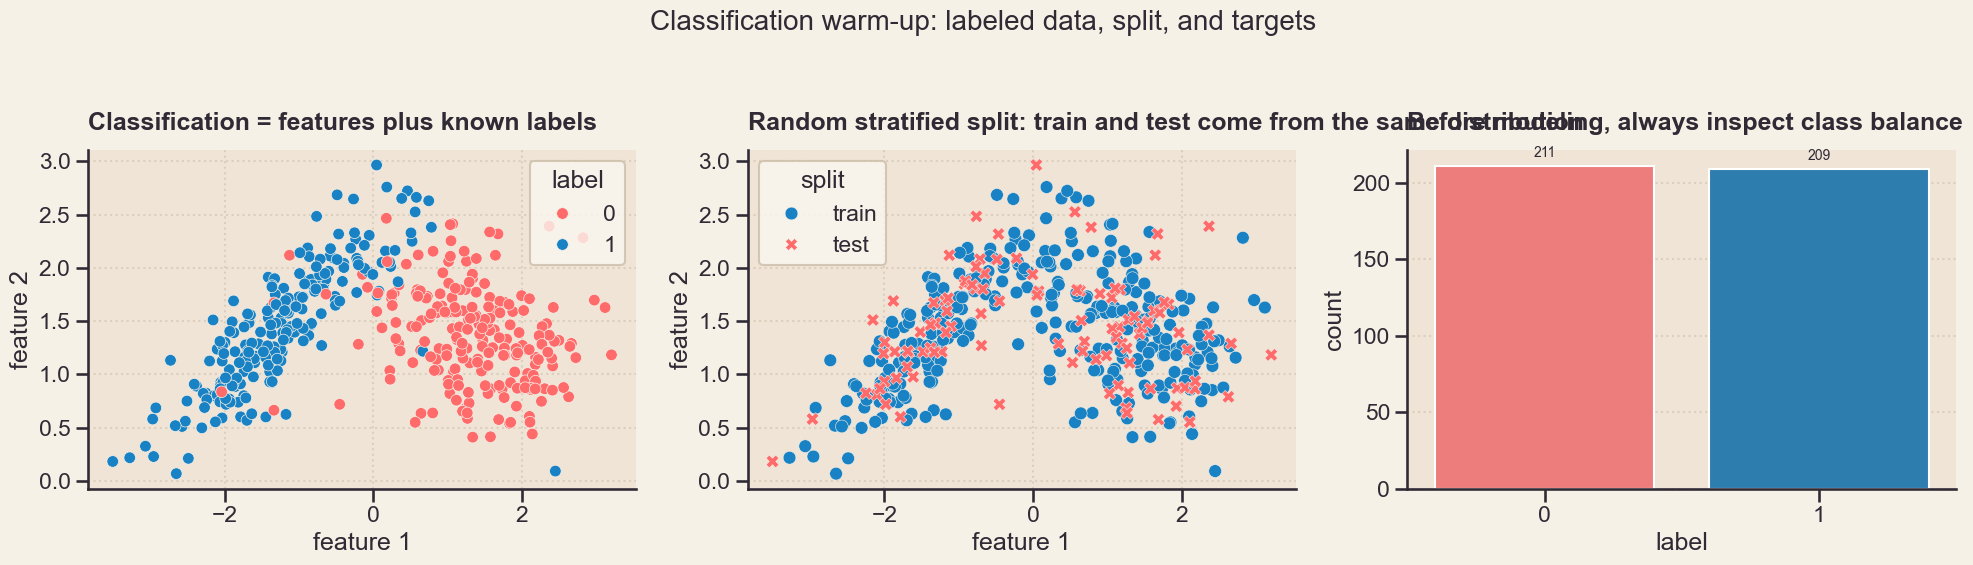

,feature_1,feature_2,label
0,-1.106698,1.660291,1
1,1.385041,1.551358,0
2,0.051365,1.744050,1
3,-0.223663,2.089217,1
4,1.764512,1.676605,0


In [4]:
X_intro, y_intro = make_classification(
    n_samples=420,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.35,
    flip_y=0.03,
    random_state=21,
)

X_train_intro, X_test_intro, y_train_intro, y_test_intro = train_test_split(
    X_intro,
    y_intro,
    test_size=0.25,
    stratify=y_intro,
    random_state=42,
)

intro_frame = pd.DataFrame(X_intro, columns=["feature_1", "feature_2"])
intro_frame["label"] = y_intro

split_frame = pd.DataFrame(
    np.vstack([X_train_intro, X_test_intro]),
    columns=["feature_1", "feature_2"],
)
split_frame["label"] = np.hstack([y_train_intro, y_test_intro])
split_frame["split"] = ["train"] * len(X_train_intro) + ["test"] * len(X_test_intro)

balance_frame = (
    intro_frame["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.scatterplot(
    data=intro_frame,
    x="feature_1",
    y="feature_2",
    hue="label",
    palette=class_colors[:2],
    s=70,
    edgecolor=paper,
    linewidth=0.5,
    ax=axes[0],
)
axes[0].set_title("Classification = features plus known labels")
axes[0].set_xlabel("feature 1")
axes[0].set_ylabel("feature 2")
axes[0].legend(title="label", loc="upper right")

sns.scatterplot(
    data=split_frame,
    x="feature_1",
    y="feature_2",
    hue="split",
    style="split",
    palette={"train": "#1982c4", "test": "#ff6b6b"},
    markers={"train": "o", "test": "X"},
    s=85,
    edgecolor=paper,
    linewidth=0.4,
    ax=axes[1],
)
axes[1].set_title("Random stratified split: train and test come from the same distribution")
axes[1].set_xlabel("feature 1")
axes[1].set_ylabel("feature 2")

sns.barplot(
    data=balance_frame,
    x="label",
    y="count",
    hue="label",
    palette=class_colors[:2],
    dodge=False,
    legend=False,
    ax=axes[2],
)
annotate_bars(axes[2], offset=4, fmt="{:.0f}")
axes[2].set_title("Before modeling, always inspect class balance")
axes[2].set_xlabel("label")
axes[2].set_ylabel("count")

fig.suptitle("Classification warm-up: labeled data, split, and targets", y=1.04, fontsize=20)
fig.tight_layout()
plt.show()

intro_frame.head()


Now that the task is clear, we study two classic classification baselines:
- Logistic Regression: linear score, probabilistic output
- SVM: linear or kernel boundary, margin maximization

We start with Logistic Regression because probabilities are easy to interpret and threshold.


### Why study these two instead of a more powerful model?

- They are still strong baselines on many tabular classification problems.
- Logistic Regression teaches probabilities, log-odds, and thresholding.
- SVM teaches margins, support vectors, and the idea of kernels.
- Both are fast to train, easy to debug, and easier to explain than boosting or deep nets.
- If these simple models already work well, a more complex model may add little value.
- If they fail, that failure is informative: maybe the boundary is nonlinear, the features are weak, or the data needs better preprocessing.


## 2. Logistic Regression

Core equations:

$$
z = w^\top x + b
$$

$$
p(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
\log \frac{p}{1-p} = w^\top x + b
$$

It is linear in feature space, but probabilistic at the output.


### Odds and why we compute them

Odds are not the same as probability:

$$
\text{odds} = \frac{p}{1-p}
$$

If $p=0.8$, then

$$
\text{odds} = \frac{0.8}{0.2} = 4
$$

which means the positive class is four times as likely as the negative class.

Why do we care?
- Logistic Regression is linear in **log-odds**, not in probability.
- Taking the logarithm turns multiplicative changes in odds into additive effects.
- This is why coefficients are easy to interpret through odds ratios like $\exp(w_j)$.


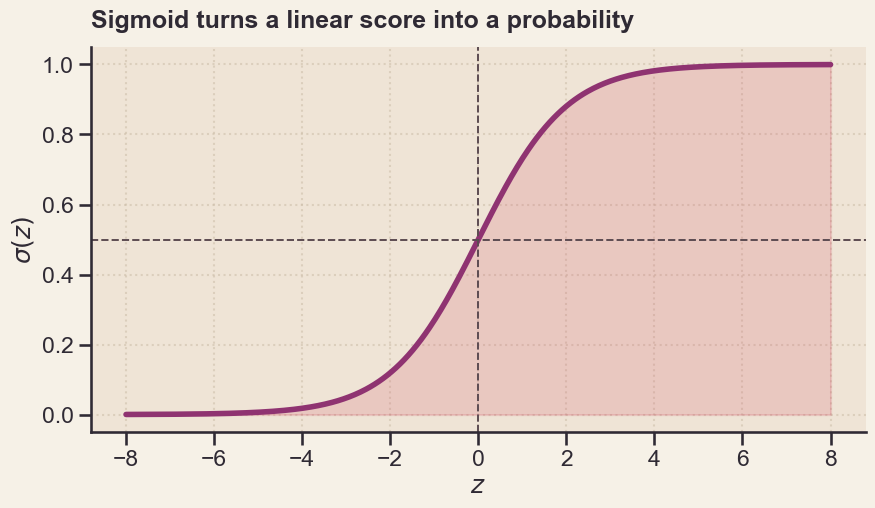

In [5]:
z = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z, sigmoid, linewidth=4, color=sns.color_palette("flare", 6)[4])
ax.fill_between(z, 0, sigmoid, color=sns.color_palette("flare", 6)[2], alpha=0.18)
ax.axhline(0.5, color="#5c4b51", linestyle="--", linewidth=1.4)
ax.axvline(0.0, color="#5c4b51", linestyle="--", linewidth=1.4)
ax.set_title("Sigmoid turns a linear score into a probability")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\sigma(z)$")
plt.show()


Training objective:

$$
L(y, p) = -\left[y \log p + (1-y)\log(1-p)\right]
$$

The model is punished most when it is very confident and wrong.


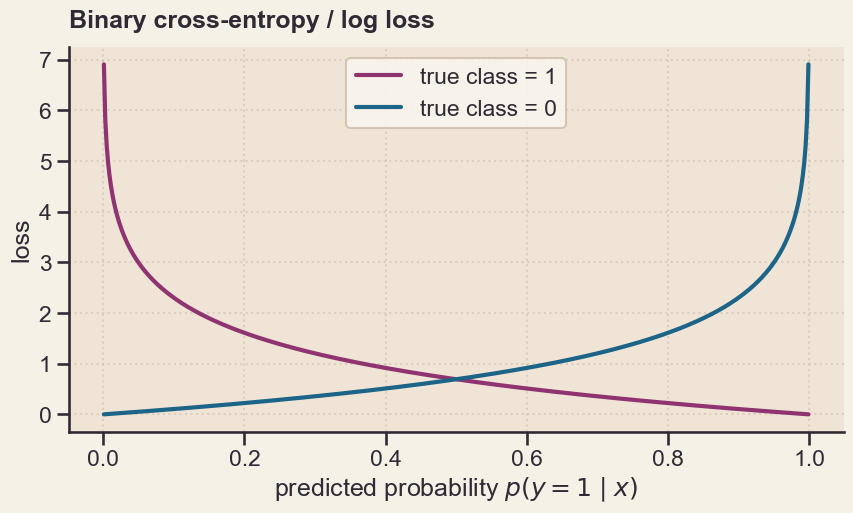

In [6]:
p = np.linspace(0.001, 0.999, 500)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p, loss_y1, label=r"true class = 1", linewidth=3, color=sns.color_palette("flare", 6)[4])
ax.plot(p, loss_y0, label=r"true class = 0", linewidth=3, color=sns.color_palette("crest", 6)[4])
ax.set_title("Binary cross-entropy / log loss")
ax.set_xlabel(r"predicted probability $p(y=1 \mid x)$")
ax.set_ylabel("loss")
ax.legend(frameon=True)
plt.show()


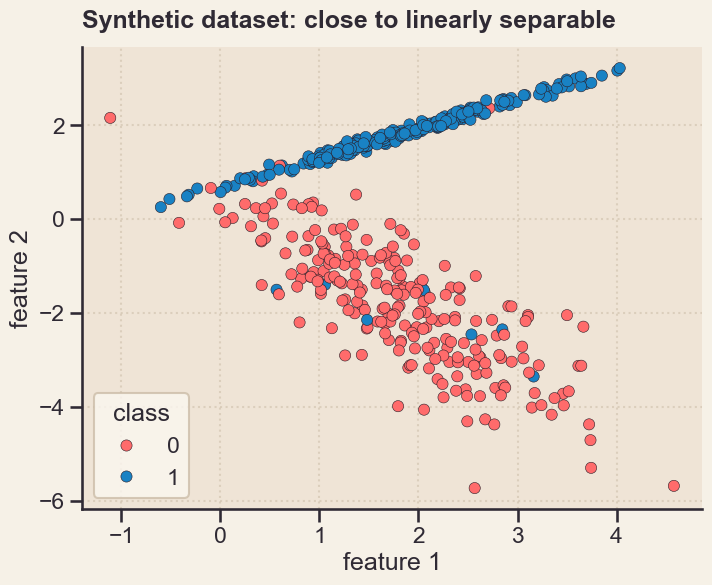

In [7]:
X_lin, y_lin = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.04,
    random_state=42,
)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin,
    y_lin,
    test_size=0.25,
    stratify=y_lin,
    random_state=42,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X_lin[:, 0],
    y=X_lin[:, 1],
    hue=y_lin,
    palette=class_colors[:2],
    s=65,
    edgecolor="#2b1d26",
    linewidth=0.4,
    ax=ax,
)
ax.set_title("Synthetic dataset: close to linearly separable")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.legend(title="class")
plt.show()


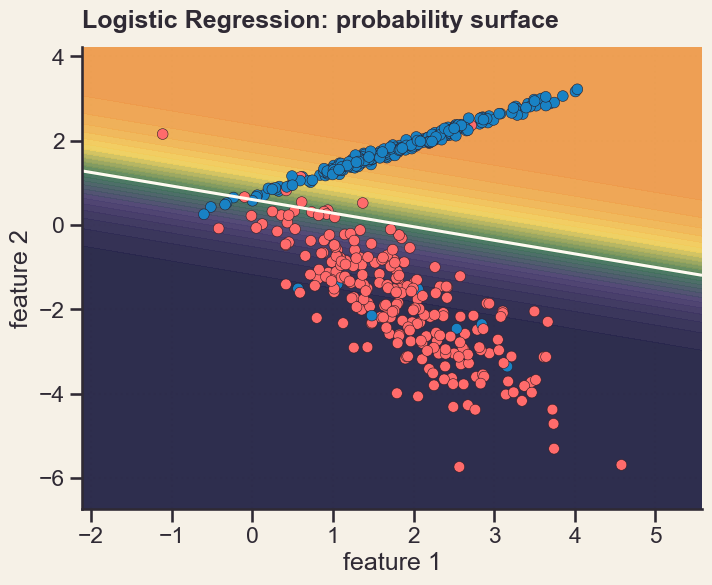

,metric,value
0,accuracy,0.952
1,precision,0.952
2,recall,0.952
3,f1,0.952
4,roc_auc,0.986


In [8]:
logreg_lin = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000)),
    ]
)
logreg_lin.fit(X_train_lin, y_train_lin)

pred_lin = logreg_lin.predict(X_test_lin)
proba_lin = logreg_lin.predict_proba(X_test_lin)[:, 1]

metrics_lin = metric_frame(y_test_lin, pred_lin, proba_lin)

fig, ax = plt.subplots(figsize=(8, 6))
plot_surface(ax, logreg_lin, X_lin, y_lin, "Logistic Regression: probability surface")
plt.show()

metrics_lin.round(3)


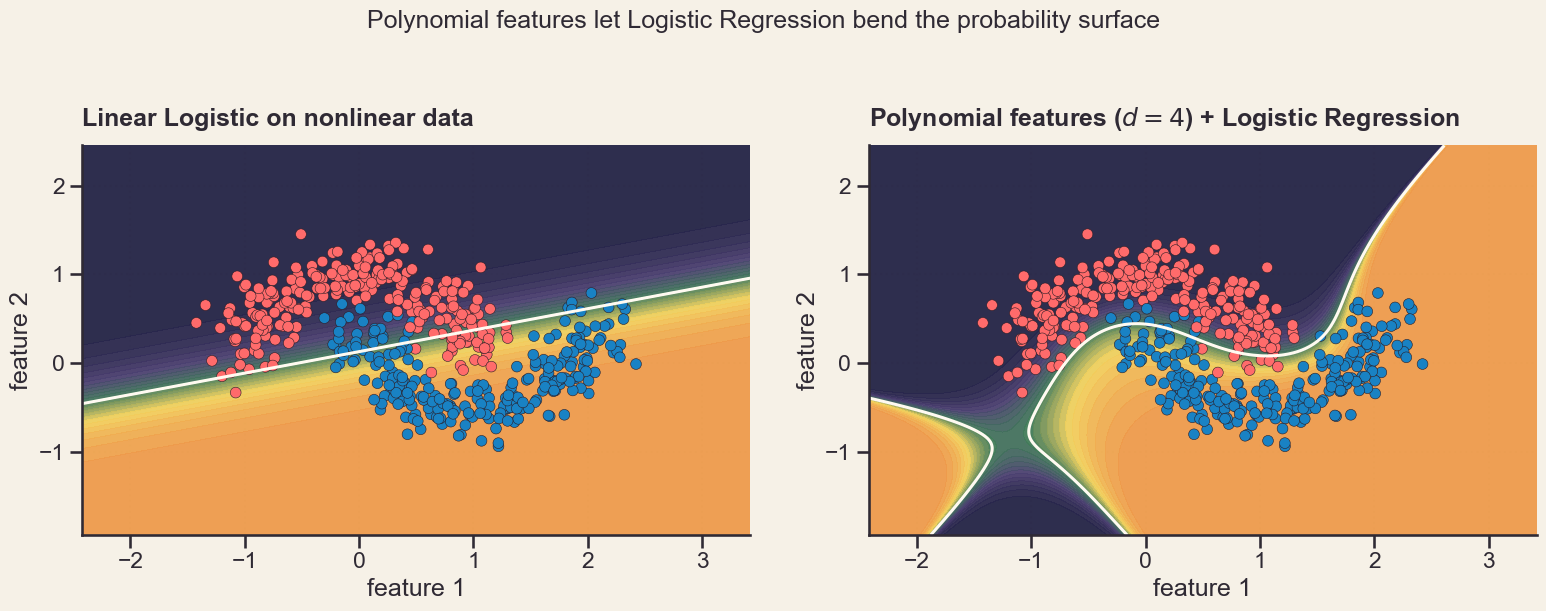

model,Linear Logistic,Polynomial Logistic
metric,,
accuracy,0.864,0.984
f1,0.862,0.984
precision,0.869,1.000
recall,0.855,0.968
roc_auc,0.948,0.996


In [9]:
X_poly_lr, y_poly_lr = make_moons(n_samples=500, noise=0.18, random_state=42)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_lr,
    y_poly_lr,
    test_size=0.25,
    stratify=y_poly_lr,
    random_state=42,
)

logreg_base = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

logreg_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

logreg_base.fit(X_train_poly, y_train_poly)
logreg_poly.fit(X_train_poly, y_train_poly)

pred_base = logreg_base.predict(X_test_poly)
proba_base = logreg_base.predict_proba(X_test_poly)[:, 1]
pred_poly = logreg_poly.predict(X_test_poly)
proba_poly = logreg_poly.predict_proba(X_test_poly)[:, 1]

poly_compare = pd.concat(
    [
        metric_frame(y_test_poly, pred_base, proba_base).assign(model="Linear Logistic"),
        metric_frame(y_test_poly, pred_poly, proba_poly).assign(model="Polynomial Logistic"),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_surface(axes[0], logreg_base, X_poly_lr, y_poly_lr, "Linear Logistic on nonlinear data")
plot_surface(
    axes[1],
    logreg_poly,
    X_poly_lr,
    y_poly_lr,
    r"Polynomial features ($d=4$) + Logistic Regression",
)
fig.suptitle("Polynomial features let Logistic Regression bend the probability surface", y=1.03, fontsize=18)
fig.tight_layout()
plt.show()

poly_compare.pivot(index="metric", columns="model", values="value").round(3)


# learning etap

### 1

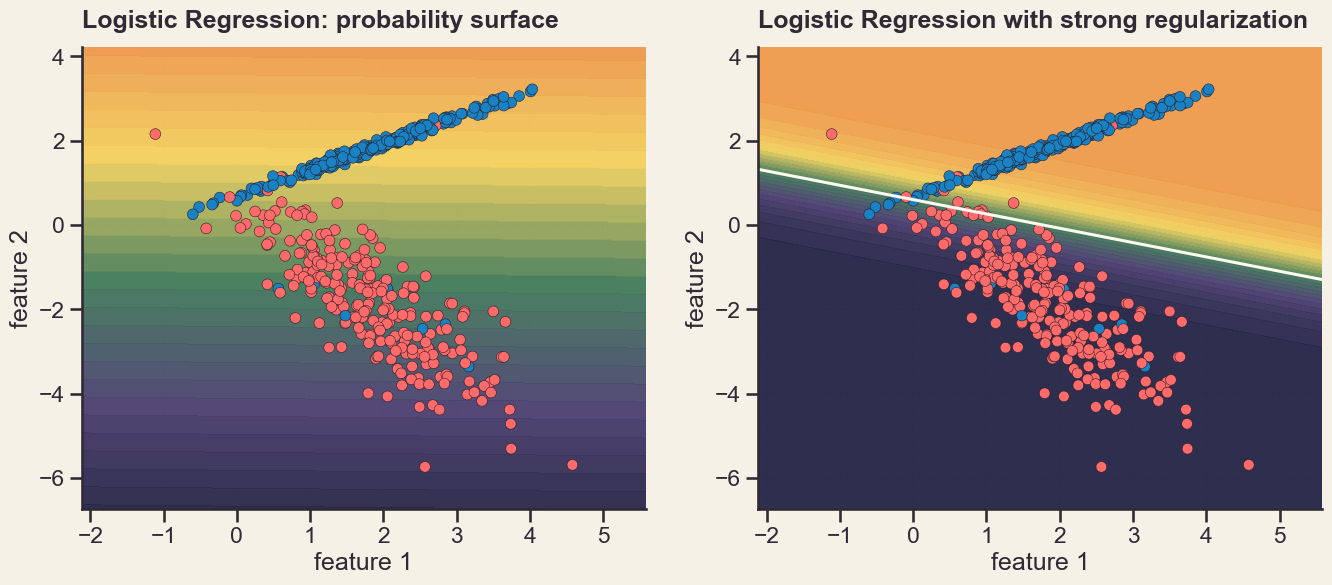

In [10]:
logreg_lin = Pipeline(
    [
        ("scarler", StandardScaler()),
        ("model", LogisticRegression(C=1e-5, max_iter=2000)),
    ]
)
logreg_lin.fit(X_train_lin, y_train_lin)

pred_lin = logreg_lin.predict(X_test_lin)
proba_lin = logreg_lin.predict_proba(X_test_lin)[:, 1]

metrics_lin = metric_frame(y_test_lin, pred_lin, proba_lin)

metrics_lin.round(3)

logreg_penalty = Pipeline(
    [
        ("scarler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000, penalty="l1", solver="liblinear")),
    ]
)
logreg_penalty.fit(X_train_lin, y_train_lin)

pred_penalty = logreg_penalty.predict(X_test_lin)
proba_penalty = logreg_penalty.predict_proba(X_test_lin)[:, 1]

metrics_penalty = metric_frame(y_test_lin, pred_penalty, proba_penalty)


fig, ax =plt.subplots(1, 2, figsize=(16, 6))
plot_surface(ax[0], logreg_lin, X_lin, y_lin, "Logistic Regression: probability surface")
plot_surface(ax[1], logreg_penalty, X_lin, y_lin, "Logistic Regression with strong regularization")
plt.show()

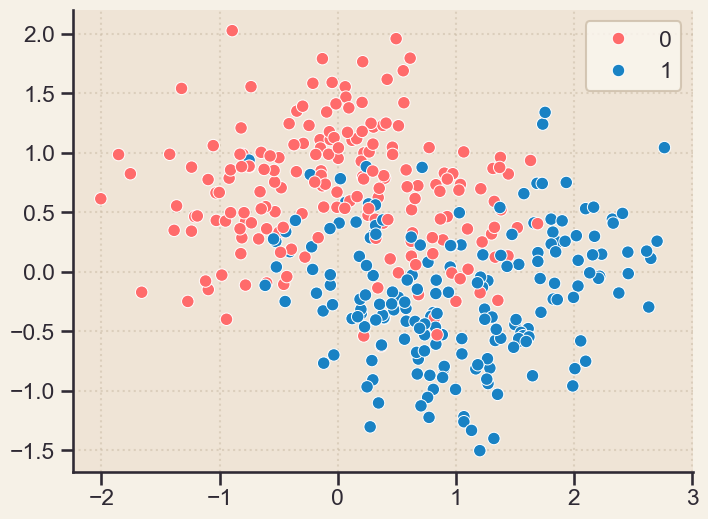

In [11]:
# generate a more moon dataset
x_moon, y_moon = make_moons(n_samples=500, noise=0.4, random_state=42)
X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    x_moon,
    y_moon,
    test_size=0.25,
    stratify=y_moon,
    random_state=42,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X_train_moon[:, 0],
    y=X_train_moon[:, 1],
    hue=y_train_moon,
    ax=ax,
)
plt.show()

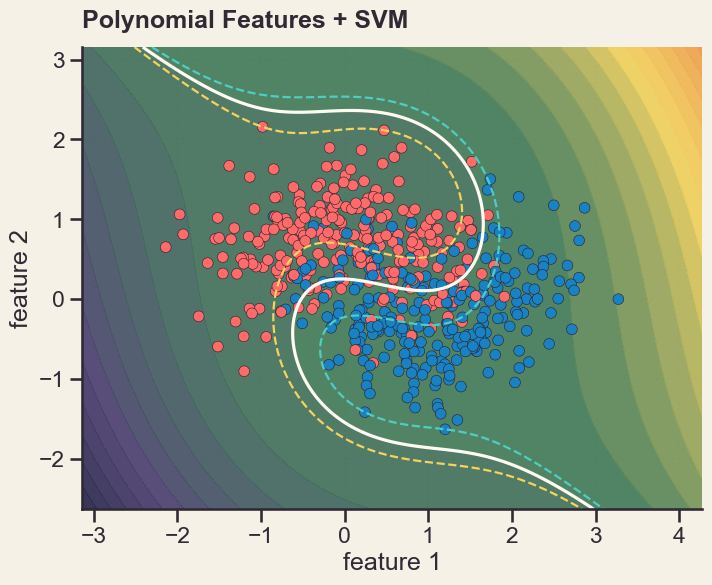

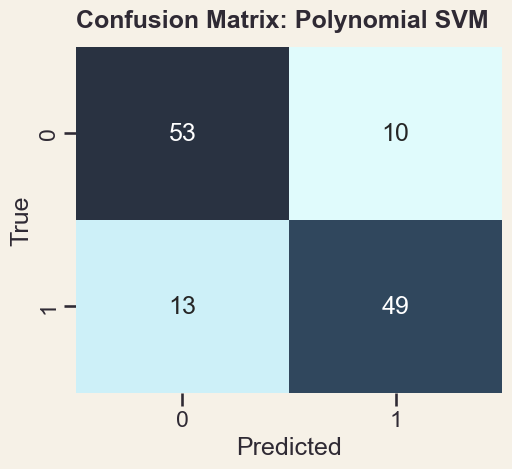

In [12]:
#  polynomial features + SVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_moon_poly = make_moons(n_samples=500, noise=0.45, random_state=42)
X_moon, y_moon = X_moon_poly

X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moon,
    y_moon,
    test_size=0.25,
    stratify=y_moon,
    random_state=42,
)

svm_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1e3, probability=True)),
    ]
)

svm_poly.fit(X_train_moon, y_train_moon)

pred_moon = svm_poly.predict(X_test_moon)

fig, ax = plt.subplots(figsize=(8, 6))
plot_margin_surface(
    ax,
    svm_poly,
    X_moon,
    y_moon,
    "Polynomial Features + SVM",
    show_support=False,
)
plt.show()

cm = confusion_matrix(y_test_moon, pred_moon)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cool_cmap,
    cbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix: Polynomial SVM")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.show()

Best params: {'model__C': 10.0, 'model__solver': 'lbfgs', 'poly__degree': 4}
Best CV score: 0.8400000000000001


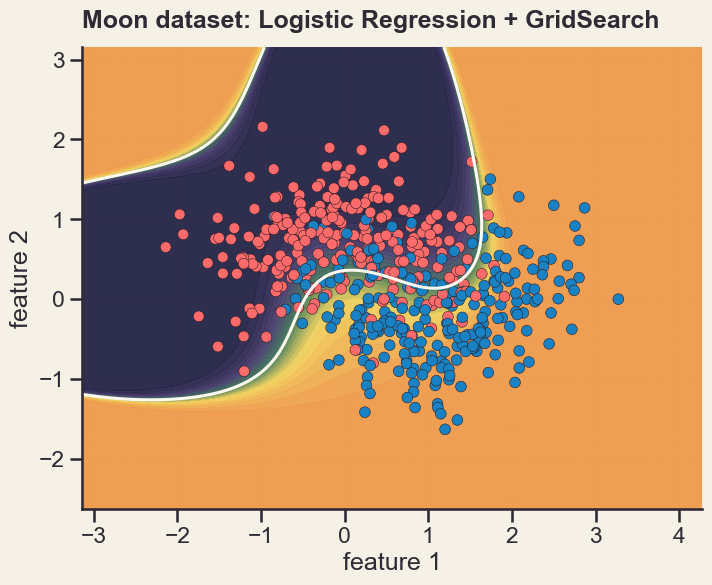

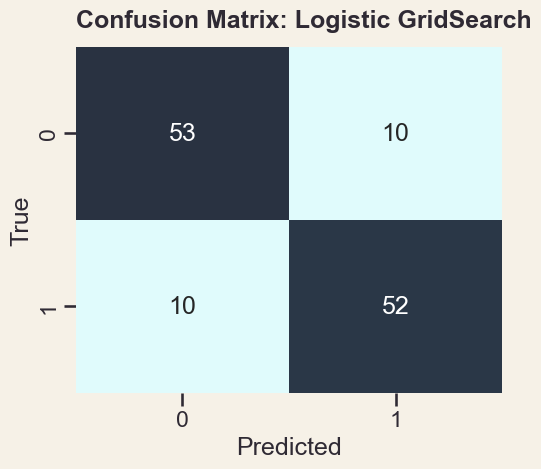

In [42]:
# Logistic Regression with grid search
logreg_grid = Pipeline(
    [
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3, 4],
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__solver": ["lbfgs"],
}

grid = GridSearchCV(
    estimator=logreg_grid,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(X_train_moon, y_train_moon)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_logreg = grid.best_estimator_
pred_moon = best_logreg.predict(X_test_moon)

fig, ax = plt.subplots(figsize=(8, 6))
plot_surface(
    ax,
    best_logreg,
    X_moon,
    y_moon,
    "Moon dataset: Logistic Regression + GridSearch",
    show_support=False,
)
plt.show()

cm = confusion_matrix(y_test_moon, pred_moon)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cool_cmap,
    cbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix: Logistic GridSearch")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.show()

# end